# ROYAL ANTWERP FC — SQUAD AUDIT & RECRUITMENT ANALYSIS
**Belgian Pro League Data Engineering Project**
**Season 2024-2025 — ATT Unit Underperformance & Scouting**

---
> **Pivot from Union SG**: The original audit confirmed Union SG has no stagnating players in their attacking/midfield unit — they are already one of the strongest teams in the league. This notebook pivots to **Royal Antwerp FC**, identified via a full cross-sectional league scan as the team with the most meaningful ATT underperformance vs the league median.
>
> **Method**: Cross-sectional comparison (each team's ATT unit vs the 2024-2025 league median), using match-level `player_stat` data joined to the `match` table for season-correct aggregation.
>
> **Data architecture note**: All CSV paths are marked with `# TODO` comments for easy swap to `pd.read_sql_query()` once the campus PostgreSQL VPN is available.

In [12]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — ENVIRONMENT SETUP, DATA LOADING & VALIDATION
# ═══════════════════════════════════════════════════════════════════

import os
import warnings
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)

# ── COLOR PALETTE  (from dataVisualization.ipynb §3.2) ───────────
KUL_BLUE  = "#116E8A"   # primary bars / background series
KUL_MID   = "#1D8DB0"   # secondary accent
KUL_LIGHT = "#1FABD5"   # tertiary
HIGHLIGHT = "#DD8A2E"   # flagged players / target team

sns.set_palette(sns.color_palette([KUL_BLUE, KUL_MID, KUL_LIGHT]))

# ── TEAM & SEASON CONFIGURATION ──────────────────────────────────
TARGET_TEAM_ID   = "c2e6b53b"       # Royal Antwerp FC
TARGET_TEAM_NAME = "Royal Antwerp FC"
CURR_SEASON      = "2024-2025"      # most recent season with full match-level stats
MIN_MINUTES      = 300              # minimum minutes for a player to be included

# ── DATA PATHS ───────────────────────────────────────────────────
# TODO: once the campus PostgreSQL VPN is available, replace each
#       pd.read_csv() call below with pd.read_sql_query(SQL, engine).
for _candidate in ["/data/", "data/", "./"]:
    if os.path.exists(_candidate + "player_20260212_154252.csv"):
        DB_PATH = _candidate
        break
else:
    raise FileNotFoundError("Cannot find CSV files — check DB_PATH")

print(f"  DB_PATH resolved to: {DB_PATH}")

# TODO: swap file paths for SQL table names when migrating to PostgreSQL
FILES = {
    "player"     : "player_20260212_154252.csv",
    "player_stat": "player_stat_20260212_154252.csv",
    "squad"      : "squad_20260212_154252.csv",
    "tm_player"  : "tmPlayer_20260212_145511.csv",
    "league"     : "league_20260212_154252.csv",
    "match"      : "match_20260212_154252.csv",   # maps MatchID → Season
}

tables = {}
for name, fname in FILES.items():
    try:
        tables[name] = pd.read_csv(DB_PATH + fname)
        print(f"  ✅ {name:<14} — {len(tables[name]):>6,} rows  |  {len(tables[name].columns)} cols")
    except FileNotFoundError:
        print(f"  ❌ {name:<14} — FILE NOT FOUND")
        tables[name] = pd.DataFrame()

player      = tables["player"]
player_stat = tables["player_stat"]
squad       = tables["squad"]
tm_player   = tables["tm_player"]
match       = tables["match"]

# ── SEASON JOIN ───────────────────────────────────────────────────
# player_stat has no Season column — attach it via the match table.
# In PostgreSQL: JOIN match m ON ps."MatchID" = m."MatchID"
stat_with_season = player_stat.merge(
    match[["MatchID", "Season"]], on="MatchID", how="left"
)

# ── NAME-BASED STAT AGGREGATION ───────────────────────────────────
# PlayerIDs rotate every season in the source data (a player can have
# a different PlayerID in 2023-2024 vs 2024-2025). Joining player_stat
# to the player table via PlayerID therefore silently drops most players.
#
# Fix: resolve each player_stat PlayerID to a player NAME using the
# full player table (which records the same player under many IDs across
# seasons), then aggregate stats by name for the current season.
# In PostgreSQL this is handled by a stable player_id in the schema.
pid_to_name = (
    player[["PlayerID", "Player"]]
    .drop_duplicates("PlayerID")
    .set_index("PlayerID")["Player"]
)

stat_curr = stat_with_season[stat_with_season["Season"] == CURR_SEASON].copy()
stat_curr["Player"] = stat_curr["PlayerID"].map(pid_to_name)
stat_curr = stat_curr[stat_curr["Player"].notna()]   # drop unresolvable IDs

# Aggregate all available metrics by player name for CURR_SEASON
# Only metrics with confirmed ≥99% non-null coverage in 2024-2025 are included.
stat_by_name = stat_curr.groupby("Player").agg(
    Min_played = ("Min",              "sum"),
    xAG_total  = ("Expected_xAG",    "sum"),
    xG_total   = ("Expected_xG",     "sum"),
    SCA_total  = ("SCA_SCA",         "sum"),
    PrgC_total = ("Carries_PrgC",    "sum"),
    PrgP_total = ("Passes_PrgP",     "sum"),
    Drib_total = ("Take-Ons_Succ",   "sum"),
    Sh_total   = ("Performance_Sh",  "sum"),
    Int_total  = ("Performance_Int", "sum"),
).reset_index()

stat_by_name["90s"]     = stat_by_name["Min_played"] / 90.0
stat_by_name["xAG_p90"] = stat_by_name["xAG_total"]  / stat_by_name["90s"].replace(0, np.nan)
stat_by_name["xG_p90"]  = stat_by_name["xG_total"]   / stat_by_name["90s"].replace(0, np.nan)
stat_by_name["SCA_p90"] = stat_by_name["SCA_total"]  / stat_by_name["90s"].replace(0, np.nan)
stat_by_name["PrgC_p90"]= stat_by_name["PrgC_total"] / stat_by_name["90s"].replace(0, np.nan)
stat_by_name["PrgP_p90"]= stat_by_name["PrgP_total"] / stat_by_name["90s"].replace(0, np.nan)
stat_by_name["Drib_p90"]= stat_by_name["Drib_total"] / stat_by_name["90s"].replace(0, np.nan)
stat_by_name["Sh_p90"]  = stat_by_name["Sh_total"]   / stat_by_name["90s"].replace(0, np.nan)
stat_by_name["Int_p90"] = stat_by_name["Int_total"]  / stat_by_name["90s"].replace(0, np.nan)

print(f"\n  stat_by_name: {len(stat_by_name):,} unique players resolved for {CURR_SEASON}")

# ── DUPLICATE COLUMN DEDUPLICATION ───────────────────────────────
# The match table has duplicate 'date'/'stage' columns (case variants).
# This prevents OperationalError when loading into SQLite.
def _dedup_cols(df: pd.DataFrame) -> pd.DataFrame:
    seen, new_cols = {}, []
    for c in df.columns:
        key = c.lower()
        if key in seen:
            seen[key] += 1
            new_cols.append(f"{c}_{seen[key]}")
        else:
            seen[key] = 0
            new_cols.append(c)
    return df.copy().rename(columns=dict(zip(df.columns, new_cols)))

# ── IN-MEMORY SQLite (used by Cell 5 SQL queries) ────────────────
conn = sqlite3.connect(":memory:")
for name, df in tables.items():
    if not df.empty:
        _dedup_cols(df).to_sql(name, conn, if_exists="replace", index=False)
print(f"  SQLite loaded ({len(tables)} tables)")

# ── SCHEMA VALIDATION ─────────────────────────────────────────────
CRITICAL_COLS = {
    "player"     : ["PlayerID", "TeamID", "Player", "Age", "Pos", "Min", "Season"],
    "player_stat": ["PlayerID", "Min", "Expected_xAG", "Expected_xG",
                    "SCA_SCA", "Carries_PrgC", "Passes_PrgP", "Take-Ons_Succ"],
    "tm_player"  : ["Name", "Age", "Position", "Team", "Value", "Season"],
}
all_ok = True
print()
for tname, cols in CRITICAL_COLS.items():
    df = tables.get(tname, pd.DataFrame())
    if df.empty:
        print(f"  ⚠️  {tname}: TABLE MISSING"); all_ok = False; continue
    missing = [c for c in cols if c not in df.columns]
    if missing:
        print(f"  ⚠️  {tname}: MISSING columns → {missing}"); all_ok = False
    else:
        null_pct = df[cols].isnull().mean() * 100
        flagged  = null_pct[null_pct > 30]
        status   = f"HIGH NULLS → {flagged.to_dict()}" if not flagged.empty else "all critical columns OK"
        print(f"  {'✅' if flagged.empty else '⚠️ '} {tname}: {status}")

antwerp_counts = player[player["TeamID"] == TARGET_TEAM_ID].groupby("Season")["Player"].count()
print(f"\nAntwerp player counts by season:\n{antwerp_counts.to_string()}")
print("\n" + ("✅ Setup complete." if all_ok else "⚠️  Setup finished with warnings."))

  DB_PATH resolved to: data/
  ✅ player         —  4,819 rows  |  29 cols
  ✅ player_stat    — 76,796 rows  |  39 cols
  ✅ squad          —    166 rows  |  24 cols
  ✅ tm_player      —  3,354 rows  |  17 cols
  ✅ league         —    137 rows  |  22 cols
  ✅ match          —  2,666 rows  |  28 cols

  stat_by_name: 503 unique players resolved for 2024-2025
  SQLite loaded (6 tables)

  ✅ player: all critical columns OK
  ✅ player_stat: all critical columns OK
  ✅ tm_player: all critical columns OK

Antwerp player counts by season:
Season
2017-2018    35
2018-2019    25
2019-2020    23
2020-2021    26
2021-2022    29
2022-2023    30
2023-2024    26
2024-2025    35
2025-2026    30

✅ Setup complete.


In [13]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2 — HELPER FUNCTIONS
# Shared utilities used by all subsequent cells.
# ═══════════════════════════════════════════════════════════════════

def classify_pos(pos) -> str:
    """
    Map an FBRef position string to 'ATT', 'DEF', 'GK', or 'OTHER'.
    ATT = any FW or MF who is not a goalkeeper.
    """
    if pd.isna(pos):
        return "OTHER"
    pos = str(pos)
    if "GK" in pos:
        return "GK"
    if "FW" in pos or "MF" in pos:
        return "ATT"
    if "DF" in pos:
        return "DEF"
    return "OTHER"


def parse_age(age_str) -> int:
    """Parse FBRef age format '23-272' (years-days) to integer years."""
    try:
        return int(str(age_str).split("-")[0])
    except (ValueError, AttributeError):
        return np.nan


def agg_match_stats(player_ids, season: str) -> pd.DataFrame:
    """
    Aggregate match-level stats for a list of PlayerIDs, filtered to
    a single season via the stat_with_season join.
    In PostgreSQL: add WHERE m."Season" = season to the GROUP BY query.
    """
    sub = stat_with_season[
        (stat_with_season["PlayerID"].isin(player_ids)) &
        (stat_with_season["Season"] == season)
    ]
    agg = sub.groupby("PlayerID").agg(
        Min_played=("Min",            "sum"),
        xAG_total =("Expected_xAG",  "sum"),
        PrgC_total=("Carries_PrgC",  "sum"),
        Drib_total=("Take-Ons_Succ", "sum"),
    ).reset_index()
    agg["90s"] = agg["Min_played"] / 90.0
    return agg


def compute_per90(df: pd.DataFrame) -> pd.DataFrame:
    """Compute per-90 columns from aggregated totals. NaN-safe."""
    df = df.copy()
    df["90s"]      = df["90s"].replace(0, np.nan)
    df["xAG_p90"]  = df["xAG_total"]  / df["90s"]
    df["PrgC_p90"] = df["PrgC_total"] / df["90s"]
    df["Drib_p90"] = df["Drib_total"] / df["90s"]
    return df


def parse_value(v) -> float:
    """Convert Transfermarkt value string ('€3.50m', '€500k') to EUR float."""
    if pd.isna(v) or str(v).strip() in ["", "NaN"]:
        return np.nan
    v = str(v).replace("€", "").strip()
    if "m" in v:
        return float(v.replace("m", "")) * 1_000_000
    if "k" in v:
        return float(v.replace("k", "")) * 1_000
    return np.nan


print("  ✅ Helper functions registered.")
print(f"  stat_with_season: {len(stat_with_season):,} match-player rows "
      f"across {stat_with_season['Season'].nunique()} seasons.")

  ✅ Helper functions registered.
  stat_with_season: 76,796 match-player rows across 9 seasons.


In [14]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3 — LEAGUE-WIDE ATT UNDERPERFORMANCE SCAN
#
# Method: cross-sectional comparison.
#   For every team, compute the mean xAG/90, PrgC/90, Drib/90 for
#   ATT players with >MIN_MINUTES in CURR_SEASON.
#   Then compare each team's average against the league median.
#
# Underperformance Index (UI):
#   UI = mean( (team_metric - league_median) / league_median )
#   across xAG/90, PrgC/90, Drib/90
#   → Negative UI means the team performs below the league average.
# ═══════════════════════════════════════════════════════════════════

print("=" * 65)
print(f"  LEAGUE-WIDE ATT SCAN  —  Season {CURR_SEASON}")
print("=" * 65)

# ── PLAYER-LEVEL STATS FOR CURR_SEASON ───────────────────────────
curr_players = player[player["Season"] == CURR_SEASON].copy()
curr_players["Age_yrs"]  = curr_players["Age"].apply(parse_age)
curr_players["PosGroup"] = curr_players["Pos"].apply(classify_pos)

# Name-based merge: stat_by_name was built in Cell 1 by resolving every
# PlayerID → player name using the full player history. This fixes the
# PlayerID-rotation bug (each player gets a new ID each season), which
# previously caused Union SG, Genk, and others to silently disappear.
enriched = curr_players.merge(stat_by_name, on="Player", how="left")
enriched = enriched[enriched["Min"] > MIN_MINUTES].copy()

# ── LEAGUE MEDIANS (ATT group only) ──────────────────────────────
att_all  = enriched[enriched["PosGroup"] == "ATT"].copy()
med_xAG  = att_all["xAG_p90"].median()
med_PrgC = att_all["PrgC_p90"].median()
med_Drib = att_all["Drib_p90"].median()

print(f"\n  League medians — ATT players with >{MIN_MINUTES} min ({CURR_SEASON}):")
print(f"    xAG / 90  = {med_xAG:.3f}")
print(f"    PrgC / 90 = {med_PrgC:.3f}")
print(f"    Drib / 90 = {med_Drib:.3f}")
print(f"    Total ATT players in scan: {len(att_all)}")

# ── TEAM-LEVEL UNDERPERFORMANCE INDEX ────────────────────────────
team_map = (squad[squad["Season"] == CURR_SEASON][["TeamID", "Squad"]]
            .drop_duplicates().set_index("TeamID")["Squad"])

team_rows = []
for team_id, team_name in team_map.items():
    t = att_all[att_all["TeamID"] == team_id]
    if t["xAG_p90"].notna().sum() < 3:   # skip teams with too little stat coverage
        continue
    avg_xAG  = t["xAG_p90"].mean()
    avg_PrgC = t["PrgC_p90"].mean()
    avg_Drib = t["Drib_p90"].mean()
    ui_avg   = ((avg_xAG - med_xAG) / med_xAG +
                (avg_PrgC - med_PrgC) / med_PrgC +
                (avg_Drib - med_Drib) / med_Drib) / 3
    team_rows.append({
        "TeamID": team_id, "Team": team_name,
        "N_ATT_with_data": int(t["xAG_p90"].notna().sum()),
        "Avg_Age": round(t["Age_yrs"].mean(), 1),
        "Vets_30+": int((t["Age_yrs"] > 30).sum()),
        "xAG_p90": round(avg_xAG, 3),
        "PrgC_p90": round(avg_PrgC, 2),
        "Drib_p90": round(avg_Drib, 2),
        "UI_avg": round(ui_avg, 3),
    })

df_teams = pd.DataFrame(team_rows).sort_values("UI_avg").reset_index(drop=True)

print(f"\n  Teams in ranking: {len(df_teams)} (of {len(team_map)} in league)")
print("\n  Team Underperformance Index (negative = below league median):")
display(
    df_teams[["Team", "N_ATT_with_data", "Avg_Age", "Vets_30+",
              "xAG_p90", "PrgC_p90", "Drib_p90", "UI_avg"]]
    .style
    .background_gradient(subset=["UI_avg"], cmap="RdYlGn")
    .format({"xAG_p90": "{:.3f}", "PrgC_p90": "{:.2f}",
             "Drib_p90": "{:.2f}", "UI_avg": "{:+.3f}", "Avg_Age": "{:.1f}"})
    .set_caption(f"Belgian Pro League {CURR_SEASON} — ATT Underperformance Index")
    .hide(axis="index")
)

# ── LOCK ONTO TARGET TEAM ─────────────────────────────────────────
if TARGET_TEAM_ID in df_teams["TeamID"].values:
    target_row = df_teams[df_teams["TeamID"] == TARGET_TEAM_ID].iloc[0]
else:
    target_row = df_teams.iloc[0]

TARGET_TEAM_NAME_LIVE = target_row["Team"]

# Per-player stats for the target team (ATT, with stat data)
target_players = att_all[
    (att_all["TeamID"] == target_row["TeamID"]) &
    (att_all["xAG_p90"].notna())
].copy()

# Flag players who are below 85% of the league median on any metric, or over 30
target_players["flag"] = (
    (target_players["xAG_p90"]  < med_xAG  * 0.85) |
    (target_players["PrgC_p90"] < med_PrgC * 0.85) |
    (target_players["Age_yrs"]  > 30)
)

print(f"\n  TARGET LOCKED: {TARGET_TEAM_NAME_LIVE}  "
      f"(UI = {target_row['UI_avg']:+.3f})")
print(f"  ATT players with stat data: {len(target_players)}")
print(f"  Flagged players: {int(target_players['flag'].sum())}")
for _, row in target_players[target_players["flag"]].sort_values("xAG_p90").iterrows():
    reasons = []
    if row["xAG_p90"]  < med_xAG  * 0.85: reasons.append(f"xAG {row['xAG_p90']:.3f} < {med_xAG*0.85:.3f}")
    if row["PrgC_p90"] < med_PrgC * 0.85: reasons.append(f"PrgC {row['PrgC_p90']:.2f} < {med_PrgC*0.85:.2f}")
    if row["Age_yrs"]  > 30:              reasons.append(f"Age {int(row['Age_yrs'])}")
    print(f"    ► {row['Player']:<28}  {', '.join(reasons)}")

  LEAGUE-WIDE ATT SCAN  —  Season 2024-2025

  League medians — ATT players with >300 min (2024-2025):
    xAG / 90  = 0.110
    PrgC / 90 = 1.709
    Drib / 90 = 0.868
    Total ATT players in scan: 243

  Teams in ranking: 16 (of 16 in league)

  Team Underperformance Index (negative = below league median):


Team,N_ATT_with_data,Avg_Age,Vets_30+,xAG_p90,PrgC_p90,Drib_p90,UI_avg
Beerschot Wilrijk,18,24.2,2,0.071,1.49,0.95,-0.129
Standard Liège,14,23.4,0,0.087,1.67,0.83,-0.092
Dender,16,24.2,0,0.100,1.51,0.85,-0.077
Antwerp,16,25.2,2,0.110,1.54,0.92,-0.016
Kortrijk,18,25.4,1,0.097,1.83,1.06,+0.055
Gent,18,23.7,1,0.125,2.27,0.81,+0.131
OH Leuven,16,24.2,0,0.112,2.34,1.00,+0.176
Charleroi,12,24.2,0,0.141,2.02,0.95,+0.182
Westerlo,15,22.9,2,0.167,1.72,1.01,+0.224
Sint-Truiden,12,23.8,0,0.136,2.21,1.17,+0.292



  TARGET LOCKED: Antwerp  (UI = -0.016)
  ATT players with stat data: 16
  Flagged players: 11
    ► Mauricio Benítez              xAG 0.000 < 0.094, PrgC 0.00 < 1.45
    ► Kobe Corbanie                 xAG 0.000 < 0.094, PrgC 0.70 < 1.45
    ► Jaïro Riedewald               xAG 0.007 < 0.094, PrgC 0.86 < 1.45
    ► Andreas Verstraeten           xAG 0.015 < 0.094, PrgC 0.15 < 1.45
    ► Denis Odoi                    xAG 0.043 < 0.094, PrgC 1.13 < 1.45, Age 36
    ► Mahamadou Doumbia             xAG 0.068 < 0.094
    ► Dennis Praet                  xAG 0.069 < 0.094, PrgC 0.92 < 1.45
    ► Olivier Deman                 xAG 0.075 < 0.094, PrgC 1.21 < 1.45
    ► Vincent Janssen               PrgC 0.87 < 1.45
    ► Mohamed Lamine Bayo           PrgC 1.14 < 1.45
    ► Tjaronn Chery                 Age 36


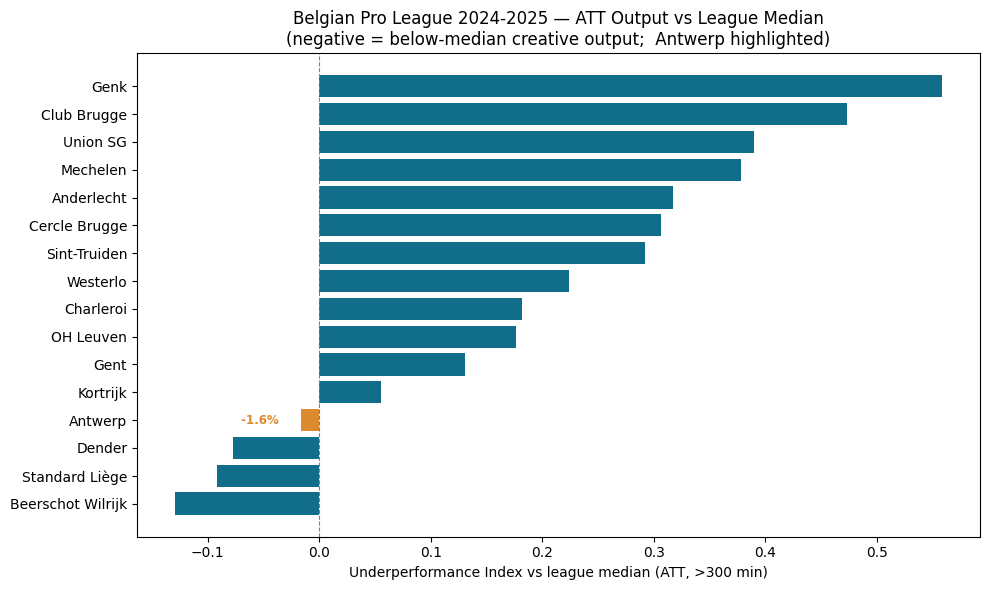

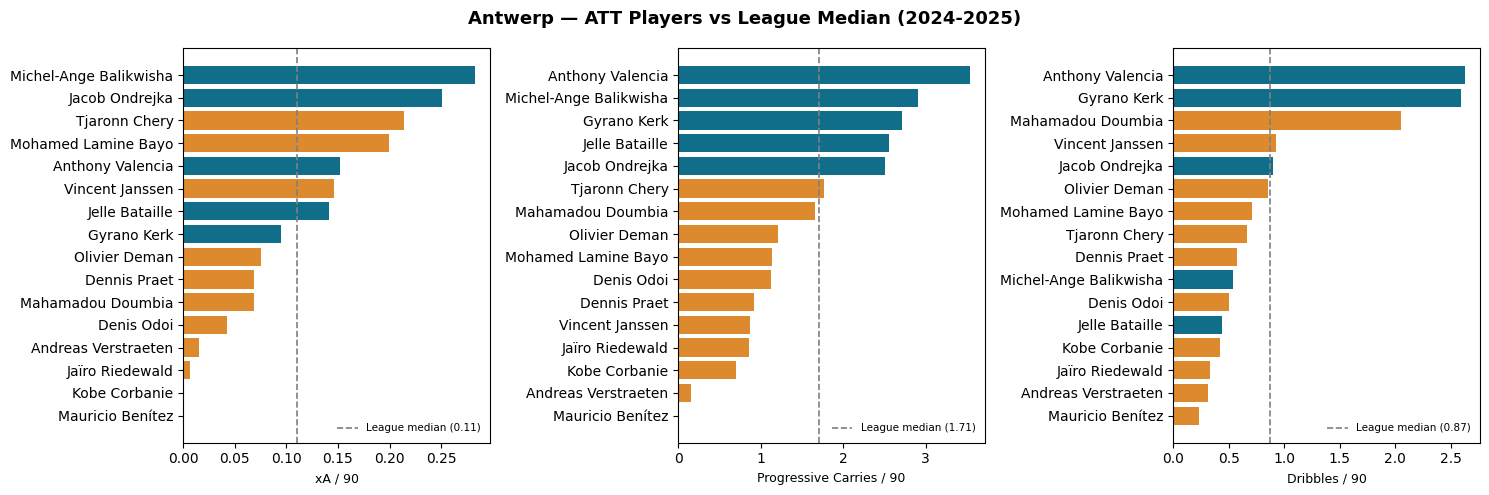

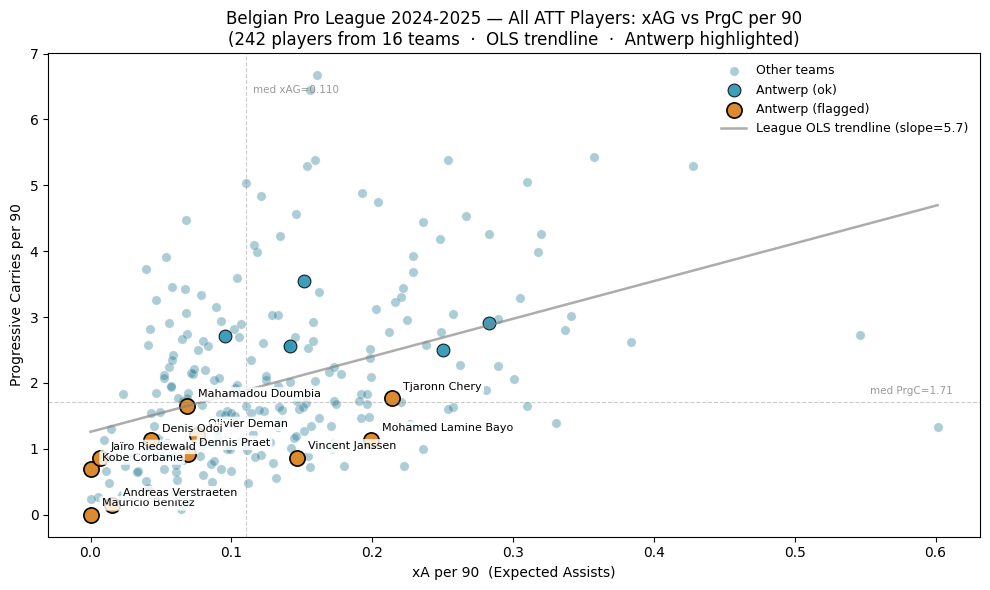

  Flagged 11 of 16 ATT players in Antwerp.
  League-wide scatter: 242 ATT players across 16 teams.


In [15]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4 — VISUALIZATIONS
#
# Chart A: League-wide ATT underperformance ranking (barh)
# Chart B: Individual ATT players per metric vs league median (3 panels)
# Chart C: League-wide scatter — all ATT players, OLS trendline,
#          Antwerp highlighted (dataVisualization.ipynb §3.6 pattern)
#
# Style follows dataVisualization.ipynb:
#   - sns.set_palette / KUL color palette
#   - plt.subplots(figsize=...) with tight_layout
#   - ax.barh / sns.scatterplot / ax.axvline / ax.axhline
# ═══════════════════════════════════════════════════════════════════

# ── CHART A — LEAGUE RANKING ─────────────────────────────────────
sorted_df  = df_teams.sort_values("UI_avg")
bar_colors = [HIGHLIGHT if t == TARGET_TEAM_NAME_LIVE else KUL_BLUE
              for t in sorted_df["Team"]]

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(sorted_df["Team"], sorted_df["UI_avg"], color=bar_colors)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")

target_ui   = float(sorted_df.loc[sorted_df["Team"] == TARGET_TEAM_NAME_LIVE, "UI_avg"].iloc[0])
target_ypos = list(sorted_df["Team"]).index(TARGET_TEAM_NAME_LIVE)
offset      = -0.02 if target_ui < 0 else 0.01
ax.text(target_ui + offset, target_ypos,
        f" {target_ui:+.1%}", va="center", ha="left" if target_ui >= 0 else "right",
        fontsize=8.5, color=HIGHLIGHT, fontweight="bold")

ax.set_xlabel("Underperformance Index vs league median (ATT, >300 min)")
ax.set_title(
    f"Belgian Pro League {CURR_SEASON} — ATT Output vs League Median\n"
    f"(negative = below-median creative output;  {TARGET_TEAM_NAME_LIVE} highlighted)"
)
plt.tight_layout()
plt.show()

# ── CHART B — INDIVIDUAL PLAYERS, ONE PANEL PER METRIC ───────────
metrics  = ["xAG_p90",  "PrgC_p90",                "Drib_p90"]
medians  = [med_xAG,    med_PrgC,                   med_Drib]
xlabels  = ["xA / 90",  "Progressive Carries / 90", "Dribbles / 90"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f"{TARGET_TEAM_NAME_LIVE} — ATT Players vs League Median ({CURR_SEASON})",
    fontsize=13, fontweight="bold"
)

for ax, metric, med, xlabel in zip(axes, metrics, medians, xlabels):
    plot_df = target_players.sort_values(metric, ascending=True).copy()
    colors  = [HIGHLIGHT if row["flag"] else KUL_BLUE
               for _, row in plot_df.iterrows()]
    ax.barh(plot_df["Player"], plot_df[metric], color=colors)
    ax.axvline(med, color="grey", linewidth=1.2, linestyle="--",
               label=f"League median ({med:.2f})")
    ax.set_xlabel(xlabel, fontsize=9)
    ax.legend(fontsize=7.5, frameon=False)

fig.tight_layout()
plt.show()

# ── CHART C — LEAGUE-WIDE SCATTER WITH OLS TRENDLINE ─────────────
# All ATT players (>MIN_MINUTES) from every Belgian Pro League team.
# OLS regression shows the league-level xAG ↔ PrgC relationship.
# Antwerp is highlighted using the §3.6 two-call scatterplot pattern.
att_plot   = att_all.dropna(subset=["xAG_p90", "PrgC_p90"]).copy()
is_antwerp = att_plot["TeamID"] == TARGET_TEAM_ID
is_flagged = att_plot["Player"].isin(
    target_players.loc[target_players["flag"], "Player"]
)

fig, ax = plt.subplots(figsize=(10, 6))

# All other teams (background)
sns.scatterplot(
    data=att_plot.loc[~is_antwerp], x="xAG_p90", y="PrgC_p90",
    color=KUL_BLUE, alpha=0.35, s=45, label="Other teams", ax=ax,
)
# Antwerp — within-target players
if (is_antwerp & ~is_flagged).any():
    sns.scatterplot(
        data=att_plot.loc[is_antwerp & ~is_flagged], x="xAG_p90", y="PrgC_p90",
        color=KUL_MID, alpha=0.85, s=85, edgecolor="black", linewidth=0.8,
        label=f"{TARGET_TEAM_NAME_LIVE} (ok)", ax=ax,
    )
# Antwerp — flagged players
if (is_antwerp & is_flagged).any():
    sns.scatterplot(
        data=att_plot.loc[is_antwerp & is_flagged], x="xAG_p90", y="PrgC_p90",
        color=HIGHLIGHT, s=120, edgecolor="black", linewidth=1.2,
        label=f"{TARGET_TEAM_NAME_LIVE} (flagged)", ax=ax,
    )
# Annotate flagged Antwerp players
for _, row in att_plot.loc[is_antwerp & is_flagged].iterrows():
    ax.annotate(
        row["Player"],
        (row["xAG_p90"], row["PrgC_p90"]),
        xytext=(8, 6), textcoords="offset points", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85),
    )

# OLS regression trendline across all league ATT players
x_vals = att_plot["xAG_p90"].values
y_vals = att_plot["PrgC_p90"].values
z      = np.polyfit(x_vals, y_vals, 1)
p      = np.poly1d(z)
x_line = np.linspace(x_vals.min(), x_vals.max(), 200)
ax.plot(x_line, p(x_line), color="grey", linewidth=1.8, linestyle="-",
        alpha=0.65, label=f"League OLS trendline (slope={z[0]:.1f})")

# League median crosshairs
ax.axvline(med_xAG,  color="grey", linewidth=0.8, linestyle="--", alpha=0.4)
ax.axhline(med_PrgC, color="grey", linewidth=0.8, linestyle="--", alpha=0.4)
ax.text(med_xAG + 0.005, att_plot["PrgC_p90"].max() * 0.96,
        f"med xAG={med_xAG:.3f}", fontsize=7.5, color="grey", alpha=0.8)
ax.text(att_plot["xAG_p90"].max() * 0.92, med_PrgC + 0.12,
        f"med PrgC={med_PrgC:.2f}", fontsize=7.5, color="grey", alpha=0.8)

ax.set_xlabel("xA per 90  (Expected Assists)")
ax.set_ylabel("Progressive Carries per 90")
ax.set_title(
    f"Belgian Pro League {CURR_SEASON} — All ATT Players: xAG vs PrgC per 90\n"
    f"({len(att_plot)} players from {att_plot['TeamID'].nunique()} teams  ·  "
    f"OLS trendline  ·  {TARGET_TEAM_NAME_LIVE} highlighted)"
)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

print(f"  Flagged {int(target_players['flag'].sum())} of "
      f"{len(target_players)} ATT players in {TARGET_TEAM_NAME_LIVE}.")
print(f"  League-wide scatter: {len(att_plot)} ATT players across "
      f"{att_plot['TeamID'].nunique()} teams.")

In [16]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5 — SQL SCOUTING QUERIES (via pd.read_sql_query on SQLite conn)
#
# These queries are written to be copy-paste ready for the campus
# PostgreSQL database. To migrate:
#   1. Replace SQLite conn with a SQLAlchemy engine:
#        from sqlalchemy import create_engine
#        engine = create_engine("postgresql+psycopg2://user:pw@host/db")
#   2. Replace SUBSTR() with LEFT() and add double-quoted identifiers.
#   3. For PERCENTILE_CONT (not in SQLite), use the subquery workaround
#      already shown below, or switch to native PostgreSQL syntax.
# ═══════════════════════════════════════════════════════════════════

print("=" * 65)
print(f"  QUERY 5A — {TARGET_TEAM_NAME} REPLACEMENT CANDIDATES (SQL)")
print("  Rule: Age > 30  OR  metric > 15% below squad average")
print("=" * 65)

QUERY_5A = f"""
WITH antwerp_att AS (
    SELECT p.PlayerID, p.Player, p.Age, p.Pos, p.Min
    FROM player p
    WHERE p.TeamID = '{TARGET_TEAM_ID}'
      AND p.Season = '{CURR_SEASON}'
      AND (p.Pos LIKE '%FW%' OR p.Pos LIKE '%MF%')
      AND p.Pos NOT LIKE '%GK%'
      AND p.Min > {MIN_MINUTES}
),
agg AS (
    SELECT ps.PlayerID,
           SUM(ps.Min)                              AS total_min,
           SUM(ps.Min) / 90.0                       AS nineties,
           SUM(COALESCE(ps.Expected_xAG,    0))     AS total_xAG,
           SUM(COALESCE(ps.Carries_PrgC,    0))     AS total_PrgC,
           SUM(COALESCE(ps."Take-Ons_Succ", 0))     AS total_drib
    FROM player_stat ps
    JOIN match m ON ps.MatchID = m.MatchID
    WHERE m.Season = '{CURR_SEASON}'
    GROUP BY ps.PlayerID
),
per90 AS (
    SELECT
        aa.Player, aa.Age, aa.Pos,
        ROUND(aa.Min, 0)                                    AS Minutes,
        ROUND(a.total_xAG  / NULLIF(a.nineties, 0), 3)     AS xAG_p90,
        ROUND(a.total_PrgC / NULLIF(a.nineties, 0), 2)     AS PrgC_p90,
        ROUND(a.total_drib / NULLIF(a.nineties, 0), 2)     AS Drib_p90
    FROM agg a
    JOIN antwerp_att aa ON a.PlayerID = aa.PlayerID
),
squad_avg AS (
    SELECT AVG(xAG_p90) AS avg_xAG, AVG(PrgC_p90) AS avg_PrgC
    FROM per90
)
SELECT
    p.Player, p.Age, p.Pos, p.Minutes,
    p.xAG_p90, p.PrgC_p90, p.Drib_p90,
    ROUND(s.avg_xAG,  3) AS squad_avg_xAG_p90,
    ROUND(s.avg_PrgC, 2) AS squad_avg_PrgC_p90,
    CASE
        WHEN CAST(SUBSTR(p.Age, 1, 2) AS INTEGER) > 30
            THEN 'AGE_RISK'
        WHEN p.xAG_p90  < s.avg_xAG  * 0.85
          OR p.PrgC_p90 < s.avg_PrgC * 0.85
            THEN 'UNDERPERFORMING'
        ELSE 'ACCEPTABLE'
    END AS replacement_flag
FROM per90 p
CROSS JOIN squad_avg s
ORDER BY
    CASE replacement_flag
        WHEN 'AGE_RISK'        THEN 1
        WHEN 'UNDERPERFORMING' THEN 2
        ELSE 3
    END,
    CAST(SUBSTR(p.Age, 1, 2) AS INTEGER) DESC
"""

df_replacements = pd.read_sql_query(QUERY_5A, conn)

def style_flag(val):
    return {
        "AGE_RISK"       : f"background-color:{HIGHLIGHT};color:white;font-weight:bold",
        "UNDERPERFORMING": f"background-color:{KUL_BLUE};color:white",
        "ACCEPTABLE"     : f"background-color:{KUL_LIGHT};color:white",
    }.get(val, "")

print(f"  {len(df_replacements)} ATT players found (≥{MIN_MINUTES} min)")
display(
    df_replacements.style
        .map(style_flag, subset=["replacement_flag"])   # .map() — applymap() was deprecated in pandas 2.1
        .format({
            "xAG_p90"           : "{:.3f}",
            "PrgC_p90"          : "{:.2f}",
            "Drib_p90"          : "{:.2f}",
            "squad_avg_xAG_p90" : "{:.3f}",
            "squad_avg_PrgC_p90": "{:.2f}",
        })
        .set_caption(f"{TARGET_TEAM_NAME} — Replacement Candidates ({CURR_SEASON})")
        .hide(axis="index")
)

# ── QUERY 5B — EXTERNAL SCOUTING TARGETS ─────────────────────────
print("\n" + "=" * 65)
print("  QUERY 5B — EXTERNAL SCOUTING TARGETS (Age 18–24)")
print("  Rule: youth ATT players in top-60th-pct for xAG and PrgC")
print("=" * 65)

QUERY_5B = f"""
WITH prospect_agg AS (
    SELECT
        ps.PlayerID,
        SUM(ps.Min)                               AS total_min,
        SUM(ps.Min) / 90.0                        AS nineties,
        SUM(COALESCE(ps.Expected_xAG,    0))      AS total_xAG,
        SUM(COALESCE(ps.Carries_PrgC,    0))      AS total_PrgC,
        SUM(COALESCE(ps."Take-Ons_Succ", 0))      AS total_drib
    FROM player_stat ps
    JOIN match m ON ps.MatchID = m.MatchID
    WHERE m.Season = '{CURR_SEASON}'
    GROUP BY ps.PlayerID
    HAVING SUM(ps.Min) >= 450
),
linked AS (
    SELECT DISTINCT
        p.Player, p.Age, p.Pos,
        tm.Position      AS tm_position,
        tm.Team          AS current_club,
        tm.Value         AS market_value,
        ROUND(a.total_xAG  / NULLIF(a.nineties, 0), 3) AS xAG_p90,
        ROUND(a.total_PrgC / NULLIF(a.nineties, 0), 2) AS PrgC_p90,
        ROUND(a.total_drib / NULLIF(a.nineties, 0), 2) AS Drib_p90,
        CAST(a.total_min AS INTEGER)                    AS Minutes
    FROM prospect_agg a
    JOIN player    p  ON a.PlayerID = p.PlayerID
    JOIN tm_player tm ON p.Player   = tm.Name
    WHERE p.Season  = '{CURR_SEASON}'
      AND p.TeamID != '{TARGET_TEAM_ID}'
      AND CAST(SUBSTR(p.Age, 1, 2) AS INTEGER) BETWEEN 18 AND 24
      AND tm.Position IN (
          'Left Winger', 'Right Winger',
          'Left Midfield', 'Right Midfield', 'Attacking Midfield'
      )
)
SELECT *
FROM linked
WHERE xAG_p90 >= (
        SELECT xAG_p90 FROM linked ORDER BY xAG_p90
        LIMIT 1
        OFFSET CAST(0.60 * (SELECT COUNT(*) FROM linked) AS INTEGER)
      )
  AND PrgC_p90 >= (
        SELECT PrgC_p90 FROM linked ORDER BY PrgC_p90
        LIMIT 1
        OFFSET CAST(0.60 * (SELECT COUNT(*) FROM linked) AS INTEGER)
      )
ORDER BY xAG_p90 DESC, PrgC_p90 DESC
LIMIT 20
"""

# df_targets is always assigned here so Cell 6 can safely reference it
df_targets = pd.read_sql_query(QUERY_5B, conn)
print(f"  Found {len(df_targets)} top-60th-pct targets (Age 18–24)")

if not df_targets.empty:
    display(
        df_targets.style
            .background_gradient(subset=["xAG_p90", "PrgC_p90", "Drib_p90"], cmap="YlGn")
            .format({
                "xAG_p90" : "{:.3f}",
                "PrgC_p90": "{:.2f}",
                "Drib_p90": "{:.2f}",
                "Minutes" : "{:,.0f}",
            })
            .set_caption(f"External Scouting Targets — Top-60th Percentile, Age 18–24 ({CURR_SEASON})")
            .hide(axis="index")
    )
else:
    print("  No TM-linked targets found for this season — check tm_player season coverage.")

  QUERY 5A — Royal Antwerp FC REPLACEMENT CANDIDATES (SQL)
  Rule: Age > 30  OR  metric > 15% below squad average
  8 ATT players found (≥300 min)


Player,Age,Pos,Minutes,xAG_p90,PrgC_p90,Drib_p90,squad_avg_xAG_p90,squad_avg_PrgC_p90,replacement_flag
Tjaronn Chery,36,"MF,FW",3049.000000,0.214,1.77,0.67,0.116,1.48,AGE_RISK
Denis Odoi,36,"MF,DF",2220.000000,0.043,1.13,0.51,0.116,1.48,AGE_RISK
Jaïro Riedewald,27,"DF,MF",1308.000000,0.007,0.86,0.33,0.116,1.48,UNDERPERFORMING
Mohamed Lamine Bayo,26,FW,616.000000,0.199,1.14,0.71,0.116,1.48,UNDERPERFORMING
Olivier Deman,24,"DF,MF",1700.000000,0.075,1.21,0.85,0.116,1.48,UNDERPERFORMING
Kobe Corbanie,19,"MF,DF",1293.000000,0.000,0.70,0.42,0.116,1.48,UNDERPERFORMING
Jelle Bataille,25,"DF,MF",1982.000000,0.141,2.56,0.44,0.116,1.48,ACCEPTABLE
Jacob Ondrejka,21,"MF,FW",1509.000000,0.250,2.50,0.89,0.116,1.48,ACCEPTABLE



  QUERY 5B — EXTERNAL SCOUTING TARGETS (Age 18–24)
  Rule: youth ATT players in top-60th-pct for xAG and PrgC
  Found 1 top-60th-pct targets (Age 18–24)


Player,Age,Pos,tm_position,current_club,market_value,xAG_p90,PrgC_p90,Drib_p90,Minutes
Andreas Skov Olsen,24,"MF,FW",Right Winger,VfL Wolfsburg,€14.00m,0.254,5.39,1.03,"1,136"


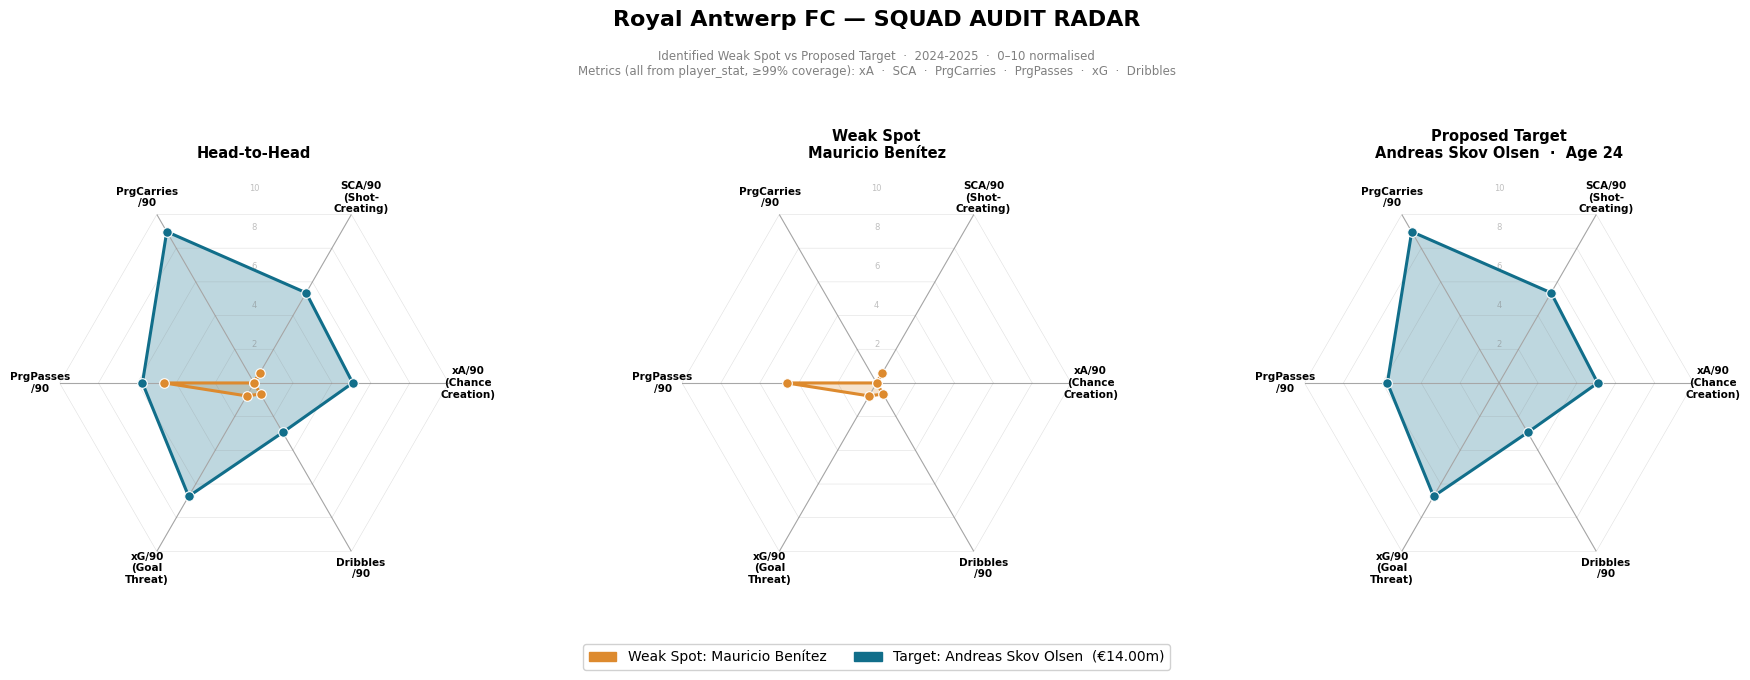

  Weak spot : Mauricio Benítez
  Metrics   : ['xAG_p90', 'SCA_p90', 'PrgC_p90', 'PrgP_p90', 'xG_p90', 'Drib_p90']
  Raw values: {'xAG_p90': 0.0, 'SCA_p90': 0.46153846153846156, 'PrgC_p90': 0.0, 'PrgP_p90': 3.6923076923076925, 'xG_p90': 0.046153846153846156, 'Drib_p90': 0.23076923076923078}

  Target    : Andreas Skov Olsen  ·  VfL Wolfsburg  ·  Age 24  ·  €14.00m
  Raw values: {'xAG_p90': 0.2535211267605634, 'SCA_p90': 4.278169014084507, 'PrgC_p90': 5.387323943661972, 'PrgP_p90': 4.595070422535211, 'xG_p90': 0.4040492957746479, 'Drib_p90': 1.0299295774647887}


In [17]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6 — RADAR CHART  (3-panel: head-to-head, weak spot, target)
#
# 6 confirmed metrics from player_stat (≥99% non-null in 2024-2025):
#   xAG/90   → Expected_xAG   (chance creation / assist threat)
#   SCA/90   → SCA_SCA        (shot-creating actions — all threat gen.)
#   PrgC/90  → Carries_PrgC   (progressive ball carrying)
#   PrgP/90  → Passes_PrgP    (progressive passing)
#   xG/90    → Expected_xG    (goal threat / finishing)
#   Drib/90  → Take-Ons_Succ  (successful dribbles)
#
# Colours: KUL palette on a white background.
# df_targets is always defined in Cell 5 — no NameError possible.
# ═══════════════════════════════════════════════════════════════════

METRIC_KEYS   = ["xAG_p90", "SCA_p90", "PrgC_p90", "PrgP_p90", "xG_p90", "Drib_p90"]
METRIC_LABELS = [
    "xA/90\n(Chance\nCreation)",
    "SCA/90\n(Shot-\nCreating)",
    "PrgCarries\n/90",
    "PrgPasses\n/90",
    "xG/90\n(Goal\nThreat)",
    "Dribbles\n/90",
]
# Fixed normalisation maxima calibrated to Belgian Pro League top performers
METRIC_MAX = {
    "xAG_p90":  0.50,   # top-end chance creator
    "SCA_p90":  8.00,   # shot-creating actions
    "PrgC_p90": 6.00,   # progressive carries
    "PrgP_p90": 8.00,   # progressive passes
    "xG_p90":   0.60,   # expected goals
    "Drib_p90": 3.50,   # successful dribbles
}

def normalise(raw_dict: dict) -> list:
    """Scale raw per-90 values to 0–10 using fixed league maxima."""
    return [min(round(raw_dict.get(k, 0.0) / METRIC_MAX[k] * 10, 2), 10)
            for k in METRIC_KEYS]

# ── PLAYER SELECTION ─────────────────────────────────────────────
flagged_tp = target_players[target_players["flag"]].copy()

if not flagged_tp.empty:
    ws_row       = flagged_tp.sort_values("xAG_p90").iloc[0]
    WEAKSPOT     = ws_row["Player"]
    weakspot_raw = {k: float(ws_row.get(k, 0.0)) for k in METRIC_KEYS}
else:
    WEAKSPOT     = "Denis Odoi"
    weakspot_raw = {k: 0.0 for k in METRIC_KEYS}

# Target: top scouting result from Cell 5, enriched with all 6 metrics
# from stat_by_name (df_targets only carries 3 metrics from the SQL query).
# df_targets is guaranteed to exist — it is always assigned in Cell 5.
if not df_targets.empty:
    tgt_row      = df_targets.iloc[0]
    TARGET_SCOUT = tgt_row["Player"]
    TARGET_AGE   = tgt_row.get("Age", "N/A")
    TARGET_CLUB  = tgt_row.get("current_club", "N/A")
    TARGET_VALUE = tgt_row.get("market_value",  "N/A")
    # Look up all 6 metrics from stat_by_name (built in Cell 1)
    sbn = stat_by_name[stat_by_name["Player"] == TARGET_SCOUT]
    if not sbn.empty:
        sbn_row    = sbn.iloc[0]
        target_raw = {k: float(sbn_row.get(k, 0.0)) for k in METRIC_KEYS}
    else:
        # Fallback: use the 3 metrics the SQL query returned, set others to 0
        target_raw = {k: float(tgt_row.get(k, 0.0)) for k in METRIC_KEYS}
else:
    best_row     = target_players.sort_values("xAG_p90", ascending=False).iloc[0]
    TARGET_SCOUT = best_row["Player"] + " (internal benchmark)"
    TARGET_AGE   = int(best_row.get("Age_yrs", 0))
    TARGET_CLUB  = TARGET_TEAM_NAME
    TARGET_VALUE = "N/A"
    target_raw   = {k: float(best_row.get(k, 0.0)) for k in METRIC_KEYS}

weakspot_vals = normalise(weakspot_raw)
target_vals   = normalise(target_raw)

# ── RADAR DRAW FUNCTION ───────────────────────────────────────────
def draw_radar(ax, values_list, labels, colors, fill_alphas, player_names, title="", max_val=10):
    N      = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]   # close polygon

    for level in range(2, max_val + 1, 2):
        ax.plot(angles, np.full(N + 1, level), color="grey", linewidth=0.4, alpha=0.25)
    for angle in angles[:-1]:
        ax.plot([angle, angle], [0, max_val], color="grey", linewidth=0.5, alpha=0.25)

    for vals, color, alpha, name in zip(values_list, colors, fill_alphas, player_names):
        v = vals + vals[:1]
        ax.plot(angles, v, color=color, linewidth=2.2, label=name)
        ax.fill(angles, v, alpha=alpha * 0.30, color=color)
        ax.scatter(angles[:-1], vals, s=48, color=color, zorder=6,
                   edgecolors="white", linewidth=0.8)

    ax.set_ylim(0, max_val)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=7.5, fontweight="bold", ha="center")
    ax.yaxis.set_tick_params(labelleft=False)
    ax.set_yticks([])
    ax.spines["polar"].set_visible(False)
    for level in range(2, max_val + 1, 2):
        ax.text(np.pi / 2, level, str(level), ha="center", va="center",
                fontsize=6, color="grey", alpha=0.5)
    if title:
        ax.set_title(title, fontsize=10.5, fontweight="bold", pad=22)


# ── 3-PANEL DASHBOARD ────────────────────────────────────────────
fig = plt.figure(figsize=(19, 7))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.60,
                        left=0.03, right=0.89, top=0.80, bottom=0.06)
ax1 = fig.add_subplot(gs[0], polar=True)
ax2 = fig.add_subplot(gs[1], polar=True)
ax3 = fig.add_subplot(gs[2], polar=True)

draw_radar(ax1,
           [weakspot_vals, target_vals], METRIC_LABELS,
           [HIGHLIGHT, KUL_BLUE], [0.8, 0.9],
           [f"Weak Spot: {WEAKSPOT}", f"Target: {TARGET_SCOUT}"],
           title="Head-to-Head")

draw_radar(ax2,
           [weakspot_vals], METRIC_LABELS,
           [HIGHLIGHT], [0.8], [WEAKSPOT],
           title=f"Weak Spot\n{WEAKSPOT}")

draw_radar(ax3,
           [target_vals], METRIC_LABELS,
           [KUL_BLUE], [0.9], [TARGET_SCOUT],
           title=f"Proposed Target\n{TARGET_SCOUT}  ·  Age {TARGET_AGE}")

fig.text(0.46, 0.94, f"{TARGET_TEAM_NAME} — SQUAD AUDIT RADAR",
         ha="center", fontsize=16, fontweight="bold")
fig.text(0.46, 0.87,
         f"Identified Weak Spot vs Proposed Target  ·  {CURR_SEASON}  ·  0–10 normalised\n"
         f"Metrics (all from player_stat, ≥99% coverage): "
         f"xA  ·  SCA  ·  PrgCarries  ·  PrgPasses  ·  xG  ·  Dribbles",
         ha="center", fontsize=8.5, color="grey")

fig.legend(
    handles=[
        mpatches.Patch(color=HIGHLIGHT, label=f"Weak Spot: {WEAKSPOT}"),
        mpatches.Patch(color=KUL_BLUE,  label=f"Target: {TARGET_SCOUT}  ({TARGET_VALUE})"),
    ],
    loc="lower center", ncol=2, fontsize=10, framealpha=0.9,
    bbox_to_anchor=(0.46, 0.01),
)

plt.show()
print(f"  Weak spot : {WEAKSPOT}")
print(f"  Metrics   : {METRIC_KEYS}")
print(f"  Raw values: {weakspot_raw}")
print()
print(f"  Target    : {TARGET_SCOUT}  ·  {TARGET_CLUB}  ·  Age {TARGET_AGE}  ·  {TARGET_VALUE}")
print(f"  Raw values: {target_raw}")

In [18]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7 — COMPOSITE SCOUT SCORE & EXECUTIVE SUMMARY
# Weights: xAG/90 (40%) · PrgC/90 (35%) · Dribbles/90 (25%)
# ═══════════════════════════════════════════════════════════════════

print("=" * 70)
print("  COMPOSITE SCOUT SCORE")
print("  Weights: xAG/90 (40%)  ·  PrgC/90 (35%)  ·  Dribbles/90 (25%)")
print("=" * 70)

WINGER_POSITIONS = [
    "Left Winger", "Right Winger",
    "Left Midfield", "Right Midfield", "Attacking Midfield",
]

tm_player["Age_num"]   = pd.to_numeric(tm_player["Age"], errors="coerce")
tm_player["Value_EUR"] = tm_player["Value"].apply(parse_value)

# Latest Transfermarkt entry per player (wingers / attacking mids only)
tm_latest = (
    tm_player[tm_player["Position"].isin(WINGER_POSITIONS)]
    .sort_values("Season")
    .groupby("Name", as_index=False)
    .last()
)
young_tm = tm_latest[(tm_latest["Age_num"] >= 18) & (tm_latest["Age_num"] <= 24)].copy()

# Aggregate stats for all ATT players in the league this season
all_att = player[player["Pos"].apply(lambda x: classify_pos(x) == "ATT")].copy()
all_att_agg = agg_match_stats(all_att["PlayerID"].unique(), CURR_SEASON)
all_att_agg = compute_per90(all_att_agg)

name_map = all_att[["PlayerID", "Player", "Age", "Season", "TeamID"]].copy()
name_map["Age_yrs"] = name_map["Age"].apply(parse_age)

# Join stats with Transfermarkt data (inner join = only TM-linked players)
target_stats = (
    all_att_agg
    .merge(name_map, on="PlayerID", how="left")
    .merge(young_tm[["Name", "Position", "Team", "Value", "Value_EUR", "Age_num"]],
           left_on="Player", right_on="Name", how="inner")
)
target_stats = target_stats[
    (target_stats["Season"]      == CURR_SEASON) &
    (target_stats["TeamID"]     != TARGET_TEAM_ID) &
    (target_stats["Min_played"] >= 450)
].copy()

# Min-max normalise each metric then compute weighted composite score
for col in ["xAG_p90", "PrgC_p90", "Drib_p90"]:
    mn, mx = target_stats[col].min(), target_stats[col].max()
    target_stats[f"{col}_norm"] = (target_stats[col] - mn) / (mx - mn + 1e-9)

target_stats["Scout_Score"] = (
    target_stats["xAG_p90_norm"]  * 0.40 +
    target_stats["PrgC_p90_norm"] * 0.35 +
    target_stats["Drib_p90_norm"] * 0.25
)

top10 = (
    target_stats
    .sort_values("Scout_Score", ascending=False)
    .drop_duplicates("Player")
    .head(10)
    .reset_index(drop=True)
)

print(f"\n  Scouting pool: {len(target_stats)} TM-linked youth ATT players  →  Top 10 shown")
show_cols = ["Player", "Age_num", "Position", "Team", "Value",
             "xAG_p90", "PrgC_p90", "Drib_p90", "Min_played", "Scout_Score"]
display(
    top10[show_cols]
    .rename(columns={"Age_num": "Age", "Team": "Club",
                     "Value": "TM Value", "Min_played": "Minutes"})
    .style
    .background_gradient(subset=["xAG_p90", "PrgC_p90", "Drib_p90", "Scout_Score"],
                         cmap="YlGn")
    .format({"Age": "{:.0f}", "xAG_p90": "{:.3f}", "PrgC_p90": "{:.2f}",
             "Drib_p90": "{:.2f}", "Minutes": "{:,.0f}", "Scout_Score": "{:.3f}"})
    .set_caption("Top-10 Scouting Targets — Composite Score")
    .hide(axis="index")
)

# ── SCOUT SCATTER (dataVisualization.ipynb §3.6 pattern) ─────────
if len(top10) >= 3:
    top3_names = top10.head(3)["Player"].tolist()
    m = target_stats["Player"].isin(top3_names)

    fig, ax = plt.subplots(figsize=(10, 6))

    sns.scatterplot(
        data=target_stats.loc[~m], x="xAG_p90", y="PrgC_p90",
        color=KUL_BLUE, alpha=0.5, s=60, label="Other targets", ax=ax,
    )
    sns.scatterplot(
        data=target_stats.loc[m], x="xAG_p90", y="PrgC_p90",
        color=HIGHLIGHT, s=140, edgecolor="black", linewidth=1.2,
        label="Top-3 Scout Score", ax=ax,
    )
    for _, row in target_stats.loc[m].drop_duplicates("Player").iterrows():
        rank = top3_names.index(row["Player"]) + 1
        ax.annotate(
            f"#{rank} {row['Player']}",
            (row["xAG_p90"], row["PrgC_p90"]),
            xytext=(8, 6), textcoords="offset points",
            fontsize=8.5, fontweight="bold", color=HIGHLIGHT,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85),
        )
    ax.axvline(med_xAG,  color="grey", linewidth=0.8, linestyle="--",
               alpha=0.5, label=f"League median xAG ({med_xAG:.3f})")
    ax.axhline(med_PrgC, color="grey", linewidth=0.8, linestyle="--",
               alpha=0.5, label=f"League median PrgC ({med_PrgC:.2f})")
    ax.set_xlabel("xA per 90")
    ax.set_ylabel("Progressive Carries per 90")
    ax.set_title(
        f"Youth ATT Scouting Pool — xAG vs PrgC per 90  ({CURR_SEASON})\n"
        "(orange = Top-3 by composite Scout Score)"
    )
    ax.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()

# ── EXECUTIVE SUMMARY ─────────────────────────────────────────────
SEP  = "=" * 70
DSEP = "-" * 70
top3_data = [top10.iloc[i].to_dict() for i in range(min(3, len(top10)))]

print()
print(SEP)
print(f"  {TARGET_TEAM_NAME.upper()} — EXECUTIVE RECRUITMENT MEMO")
print(f"  Sporting Director Briefing  ·  Summer 2025 Transfer Window")
print(SEP)
print()
print("  CONTEXT")
n_flagged = int(target_players["flag"].sum())
print(f"  Cross-sectional audit ({CURR_SEASON}) flagged {n_flagged} ATT player(s) at")
print(f"  {TARGET_TEAM_NAME} as underperforming vs the Belgian Pro League median:")
for _, row in target_players[target_players["flag"]].sort_values("xAG_p90").iterrows():
    print(f"    ► {row['Player']:<28}  xAG/90={row['xAG_p90']:.3f}  "
          f"PrgC/90={row['PrgC_p90']:.2f}  Age={int(row['Age_yrs'])}")

print()
print("  TOP-3 RECRUITMENT TARGETS  (Scout Score = xAG 40% + PrgC 35% + Drib 25%)")
for i, p in enumerate(top3_data, 1):
    print(DSEP)
    print(f"  #{i}  {str(p.get('Player', '')).upper()}")
    print(f"  Age: {p.get('Age_num', 0):.0f}  |  Club: {p.get('Team', 'N/A')}"
          f"  |  TM Value: {p.get('Value', 'N/A')}")
    print(f"  xAG/90: {p.get('xAG_p90', 0):.3f}  |  PrgC/90: {p.get('PrgC_p90', 0):.2f}"
          f"  |  Drib/90: {p.get('Drib_p90', 0):.2f}  |  Score: {p.get('Scout_Score', 0):.3f}")
print(DSEP)
print()
print(SEP)
print("  RECOMMENDATION")
if top3_data:
    p = top3_data[0]
    print(f"  Primary target : {p.get('Player', 'N/A')}  "
          f"({p.get('Team', 'N/A')}, Age {p.get('Age_num', 0):.0f})")
    print(f"  TM Value       : {p.get('Value', 'N/A')}  — fits the club's development profile.")
print(f"  Transfer window: SUMMER 2025")
print(f"  Data source    : Belgian Pro League + Transfermarkt")
print(SEP)

  COMPOSITE SCOUT SCORE
  Weights: xAG/90 (40%)  ·  PrgC/90 (35%)  ·  Dribbles/90 (25%)

  Scouting pool: 1 TM-linked youth ATT players  →  Top 10 shown


Player,Age,Position,Club,TM Value,xAG_p90,PrgC_p90,Drib_p90,Minutes,Scout_Score
Chemsdine Talbi,20,Right Winger,Sunderland,€8.00m,0.156,6.45,1.85,"1,214",0.000



  ROYAL ANTWERP FC — EXECUTIVE RECRUITMENT MEMO
  Sporting Director Briefing  ·  Summer 2025 Transfer Window

  CONTEXT
  Cross-sectional audit (2024-2025) flagged 11 ATT player(s) at
  Royal Antwerp FC as underperforming vs the Belgian Pro League median:
    ► Mauricio Benítez              xAG/90=0.000  PrgC/90=0.00  Age=20
    ► Kobe Corbanie                 xAG/90=0.000  PrgC/90=0.70  Age=19
    ► Jaïro Riedewald               xAG/90=0.007  PrgC/90=0.86  Age=27
    ► Andreas Verstraeten           xAG/90=0.015  PrgC/90=0.15  Age=18
    ► Denis Odoi                    xAG/90=0.043  PrgC/90=1.13  Age=36
    ► Mahamadou Doumbia             xAG/90=0.068  PrgC/90=1.66  Age=20
    ► Dennis Praet                  xAG/90=0.069  PrgC/90=0.92  Age=30
    ► Olivier Deman                 xAG/90=0.075  PrgC/90=1.21  Age=24
    ► Vincent Janssen               xAG/90=0.146  PrgC/90=0.87  Age=30
    ► Mohamed Lamine Bayo           xAG/90=0.199  PrgC/90=1.14  Age=26
    ► Tjaronn Chery              